# Вычисление метрик сложности текста ruTS

**Цели:**
1. Загрузить текстовые данные из split-папки (`02_text.csv`)
2. Подготовить текст для библиотеки `ruTS` (мягкая очистка)
3. Рассчитать метрики удобочитаемости и лексического разнообразия
4. Обработать отрицательные и аномальные значения метрик
5. Сохранить обогащенный текстовый датафрейм

In [1]:
# %pip install ruts

In [4]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from ruts import ReadabilityStats, DiversityStats, BasicStats

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [ ]:
file_path = "../data/split/02_text.csv"
df_text = pd.read_csv(file_path)

Функции подготовки текста для ruTS

In [ ]:
def clean_text_for_ruts(text):
    if pd.isna(text):
        return text
    
    # убираем ссылки
    text = re.sub(r'https?://[^\s]+', '', text)
    
    # убираем markdown
    text = re.sub(r'\*\*(.*?)\*\*', r'\1', text)
    text = re.sub(r'__(.*?)__', r'\1', text)
    
    # нормализуем пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df_text['text_ruts'] = df_text['text'].apply(clean_text_for_ruts)

In [59]:
def is_emoji_component(char):
    """Проверяет, является ли символ частью эмодзи"""
    cat = unicodedata.category(char)
    if cat == 'So':
        return True
    if ord(char) == 0xFE0F:
        return True
    if cat == 'Me':
        return True
    if ord(char) == 0x200D:
        return True
    if 0x1F3FB <= ord(char) <= 0x1F3FF:
        return True
    return False


def get_emoji_sequence(text, start_pos):
    """Собирает полную последовательность эмодзи"""
    i = start_pos
    while i < len(text) and is_emoji_component(text[i]):
        i += 1
    
    if start_pos > 0 and start_pos < len(text):
        prev_char = text[start_pos - 1]
        current_char = text[start_pos] if start_pos < len(text) else ''
        if (prev_char.isdigit() or prev_char in '*#') and ord(current_char) == 0xFE0F:
            if start_pos + 1 < len(text) and ord(text[start_pos + 1]) == 0x20E3:
                return i, start_pos - 1
    
    return i, start_pos


def normalize_emoji_splitters(text):
    """Заменяет эмодзи на точки с учетом контекста"""
    if not isinstance(text, str) or not text:
        return text
    
    emoji_ranges = []
    i = 0
    while i < len(text):
        if is_emoji_component(text[i]):
            end, start = get_emoji_sequence(text, i)
            emoji_ranges.append((start, end))
            i = end
        else:
            i += 1
    
    if not emoji_ranges:
        return text
    
    replacements = []
    for start, end in emoji_ranges:
        text_before = text[:start].rstrip()
        text_after = text[end:].lstrip()
        
        has_alpha_before = bool(text_before) and any(c.isalpha() for c in text_before)
        has_alpha_after = bool(text_after) and any(c.isalpha() for c in text_after)
        
        punct_before = ''
        if text_before:
            last_char = text_before[-1]
            if last_char in '.!?:;,':
                punct_before = last_char
        
        if not punct_before and start > 2:
            if text[start-1] == ' ' and text[start-2] in '.!?:;,':
                punct_before = text[start-2]
        
        if has_alpha_before and has_alpha_after:
            replacement = '' if punct_before else '. '
        else:
            replacement = ''
        
        replacements.append((start, end, replacement))
    
    result = list(text)
    for start, end, replacement in reversed(replacements):
        result[start:end] = list(replacement)
    
    return ''.join(result)


def normalize_list_markers(text):
    """Обрабатывает маркеры списков"""
    if not isinstance(text, str):
        return text
    
    # Защищаем дефисы внутри слов
    text = re.sub(r'(?<=[а-яa-z])-(?=[а-яa-z])', '___HYPHEN___', text)
    
    # Нумерованные списки
    text = re.sub(r'(?:^|\.\s|\s)(\d+)[\.\)]\s+(?=[А-ЯA-Z])', r'. \1. ', text)
    text = re.sub(r'(?<=[а-яa-z0-9])\s+(\d+)\s+(?=[А-ЯA-Z])', r'. \1. ', text)
    
    # Маркеры (буллиты, звездочки, дефисы)
    text = re.sub(r'(?:^|\.\s|\s)([•▪▸▹►▻◄◆◇○●◉◦⦁⦾⦿])\s+', r'. ', text)
    text = re.sub(r'(?:^|\.\s|\s)\*\s+(?=[А-ЯA-Zа-яa-z])', r'. ', text)
    text = re.sub(r'(?:^|\.\s|\s)\-\s+(?=[А-ЯA-Zа-яa-z])', r'. ', text)
    
    # Разделители
    text = re.sub(r'\s*;\s*', '. ', text)
    text = re.sub(r'\s*\|\s*', '. ', text)
    text = re.sub(r'\s*[→←↑↓↔↕↖↗↘↙⇒⇐⇑⇓⇔]\s*', '. ', text)
    
    # Множественные знаки
    text = re.sub(r'[!]{2,}', '!', text)
    text = re.sub(r'[?]{2,}', '?', text)
    
    # Восстанавливаем дефисы
    text = text.replace('___HYPHEN___', '-')
    
    return text


def clean_punctuation(text):
    """Финальная очистка пунктуации"""
    if not isinstance(text, str):
        return text
    
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\s+\.', '.', text)
    text = re.sub(r'\.\s*\.', '.', text)
    text = re.sub(r'([!?])\.', r'\1', text)
    text = re.sub(r':\.', ':', text)
    text = re.sub(r';\.', ';', text)
    text = re.sub(r',\.', ',', text)
    text = re.sub(r'^\.\s*', '', text)
    
    return text.strip()


def preprocess_text_for_ruts(text):
    """Полный пайплайн предобработки текста"""
    if not isinstance(text, str) or not text.strip():
        return None
    
    text = normalize_emoji_splitters(text)
    text = normalize_list_markers(text)
    text = clean_punctuation(text)
    
    # Убираем мусор
    text = re.sub(r'\(\s*\)', '', text)
    text = re.sub(r'\[\s*\]', '', text)
    text = re.sub(r'\{\s*\}', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'^\.\s*', '', text)
    text = text.strip()
    
    if len(text.split()) < 5:
        return None
    
    return text

Применяем предобработку

In [ ]:
df_text['text_ruts'] = df_text['text_ruts'].apply(preprocess_text_for_ruts)

print("\nПример обработанного текста:")
df_text['text_ruts'].iloc[0][:300]


Пример обработанного текста:
Искусственный интеллект: угроза или новые возможности? На сессии Конгресса молодых учёных, посвящённой будущему ИИ, эксперты обсудили, как совместить огромный потенциал технологии с растущими рисками. «Безусловно, нейронные сети и ИИ в целом — инструмент возможностей будущего. Но сейчас ИИ представл


Проверка валидности текстов

In [62]:
def is_valid_text_for_metrics(text):
    """
    Проверяет, подходит ли текст для расчета сложных метрик (FRE, FKG, TTR).
    
    Условия для валидности:
    - Не пустой
    - Содержит хотя бы 5 слов
    - Содержит буквы (не только эмодзи/цифры)
    """
    if not isinstance(text, str) or not text.strip():
        return False
    
    # Разбиваем на слова
    words = text.split()
    
    # Минимум 5 слов
    if len(words) < 5:
        return False
    
    # Проверяем наличие букв (русских или английских)
    has_letters = bool(re.search(r'[а-яА-Яa-zA-Z]', text))
    if not has_letters:
        return False
    
    return True

Извлечение метрик через ruTS

In [ ]:
def extract_metrics(text):
    """
    Извлекает все метрики из одного текста.
    Для коротких/невалидных текстов метрики ruTS не считаются.
    """
    
    # Проверяем, подходит ли текст для сложных метрик
    if not is_valid_text_for_metrics(text):
        # Для невалидных текстов - все метрики NaN
        return pd.Series({
            'n_words': np.nan,
            'n_sents': np.nan,
            'n_chars': np.nan,
            'words_per_sent': np.nan,
            'flesch_reading_ease': np.nan,
            'flesch_kincaid_grade': np.nan,
            'ttr': np.nan,
        })
    
    # Для валидных текстов считаем все через ruTS
    try:
        bs = BasicStats(text)
        b = bs.get_stats()
        rs = ReadabilityStats(text)
        r = rs.get_stats()
        ds = DiversityStats(text)
        d = ds.get_stats()
        
        n_words = b.get('n_words', 0)
        n_sents = b.get('n_sents', 0)
        
        return pd.Series({
            'n_words': n_words,
            'n_sents': n_sents,
            'n_chars': b.get('n_chars', 0),
            'words_per_sent': n_words / n_sents if n_sents > 0 else np.nan,
            'flesch_reading_ease': r.get('flesch_reading_easy', np.nan),
            'flesch_kincaid_grade': r.get('flesch_kincaid_grade', np.nan),
            'ttr': d.get('ttr', np.nan),
        })
    except Exception as e:

        # В случае ошибки - все метрики NaN
        return pd.Series({
            'n_words': np.nan,
            'n_sents': np.nan,
            'n_chars': np.nan,
            'words_per_sent': np.nan,
            'flesch_reading_ease': np.nan,
            'flesch_kincaid_grade': np.nan,
            'ttr': np.nan,
        })

In [64]:
# Добавляем флаг валидности текста
df_text['is_valid_for_metrics'] = df_text['text_ruts'].apply(is_valid_text_for_metrics)

valid_count = df_text['is_valid_for_metrics'].sum()
invalid_count = (~df_text['is_valid_for_metrics']).sum()

print(f"\nВалидных текстов (≥5 слов, есть буквы): {valid_count} ({valid_count/len(df_text)*100:.1f}%)")
print(f"Коротких/невалидных текстов: {invalid_count} ({invalid_count/len(df_text)*100:.1f}%)")


Валидных текстов (≥5 слов, есть буквы): 10410 (99.3%)
Коротких/невалидных текстов: 69 (0.7%)


Извлекаем метрики

In [66]:
metrics = df_text['text_ruts'].progress_apply(extract_metrics)
df_text = pd.concat([df_text, metrics], axis=1)

100%|██████████| 10479/10479 [07:54<00:00, 22.10it/s]


Проверка результатов

In [107]:
df_text[['n_words', 'n_sents', 'flesch_reading_ease', 'flesch_kincaid_grade', 'ttr', 'words_per_sent']].describe().round(2)

,n_words,n_sents,flesch_reading_ease,flesch_kincaid_grade,ttr,words_per_sent
count,10410.00,10410.00,10410.00,10410.00,10410.00,10410.00
mean,93.08,6.91,47.16,7.26,0.88,13.42
std,92.93,6.08,27.02,4.87,0.09,7.21
min,4.00,1.00,-320.91,-13.16,0.36,2.60
25%,35.00,3.00,30.38,4.32,0.82,9.50
50%,57.00,5.00,47.05,6.93,0.89,12.00
75%,114.00,8.00,63.44,9.82,0.95,15.78
max,613.00,67.00,197.74,153.45,1.00,319.00


Посмотрим сколько аномальных значений мы получили

In [108]:
fre_negative = (df_text['flesch_reading_ease'] < 0).sum()
fre_high = (df_text['flesch_reading_ease'] > 100).sum()
grade_negative = (df_text['flesch_kincaid_grade'] < 0).sum()
grade_very_high = (df_text['flesch_kincaid_grade'] > 18).sum()
ttr_high = (df_text['ttr'] > 1).sum()
wps_high = (df_text['words_per_sent'] > 50).sum()

print(f"  FRE < 0:       {fre_negative} ({fre_negative/len(df_text)*100:.2f}%)")
print(f"  FRE > 100:     {fre_high} ({fre_high/len(df_text)*100:.2f}%)")
print(f"  Grade < 0:     {grade_negative} ({grade_negative/len(df_text)*100:.2f}%)")

  FRE < 0:       405 (3.86%)
  FRE > 100:     278 (2.65%)
  Grade < 0:     368 (3.51%)


Посмотрим на распределение

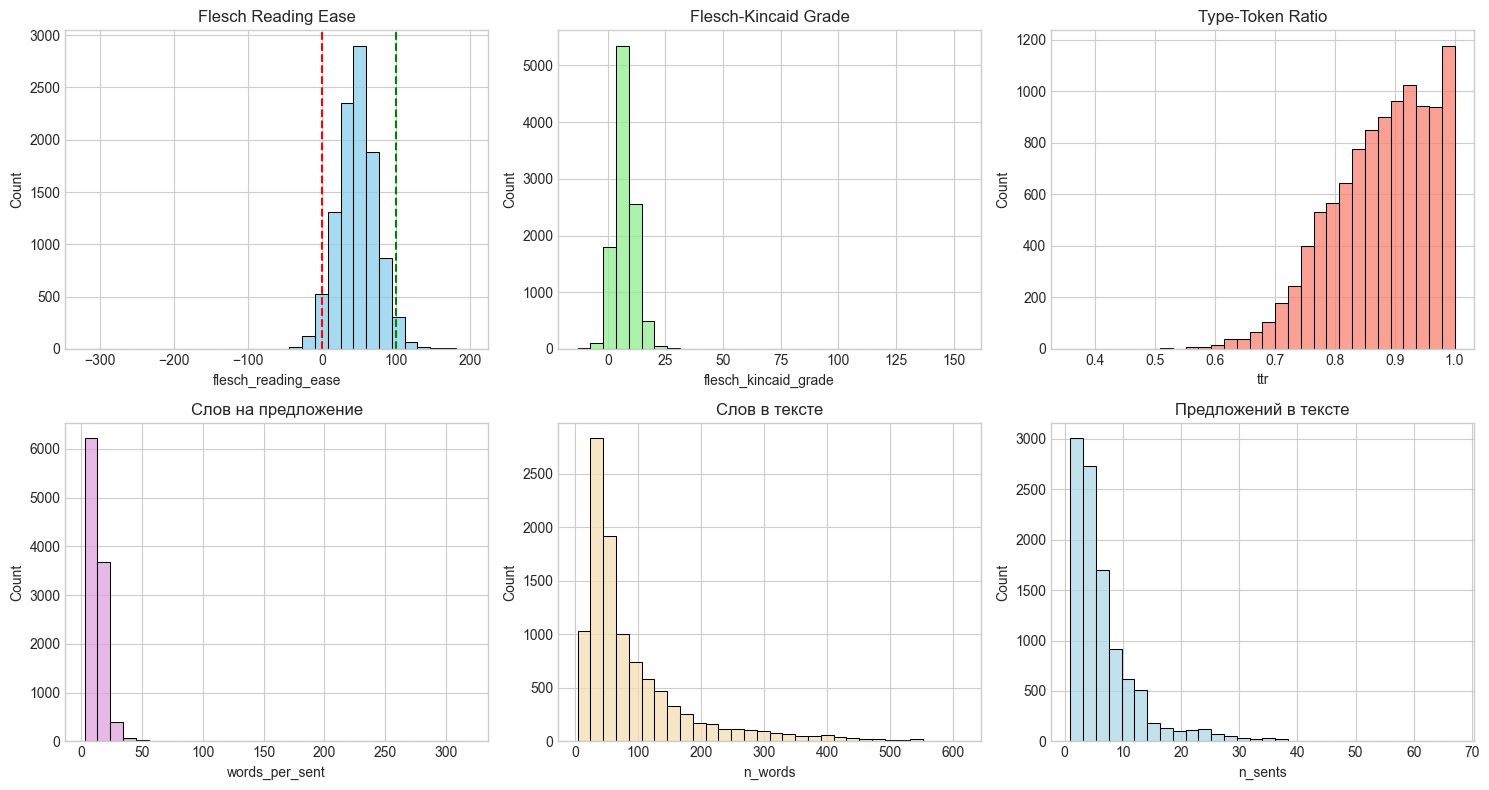

In [109]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# FRE
sns.histplot(df_text['flesch_reading_ease'].dropna(), bins=30, ax=axes[0, 0], color='skyblue')
axes[0, 0].axvline(0, color='red', linestyle='--')
axes[0, 0].axvline(100, color='green', linestyle='--')
axes[0, 0].set_title('Flesch Reading Ease')

# Grade
sns.histplot(df_text['flesch_kincaid_grade'].dropna(), bins=30, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Flesch-Kincaid Grade')

# TTR
sns.histplot(df_text['ttr'].dropna(), bins=30, ax=axes[0, 2], color='salmon')
axes[0, 2].set_title('Type-Token Ratio')

# Слов на предложение
sns.histplot(df_text['words_per_sent'].dropna(), bins=30, ax=axes[1, 0], color='plum')
axes[1, 0].set_title('Слов на предложение')

# Слов в тексте
sns.histplot(df_text['n_words'].dropna(), bins=30, ax=axes[1, 1], color='wheat')
axes[1, 1].set_title('Слов в тексте')

# Предложений в тексте
sns.histplot(df_text['n_sents'].dropna(), bins=30, ax=axes[1, 2], color='lightblue')
axes[1, 2].set_title('Предложений в тексте')

plt.tight_layout()
plt.show()

In [ ]:
def show_problems(df, n=5):
    """Показывает примеры проблемных текстов"""
    problems = {
        'FRE < 0 (очень сложные)': df[df['flesch_reading_ease'] < 0].head(n),
        'FRE > 100 (очень легкие)': df[df['flesch_reading_ease'] > 100].head(n),
        'Grade < 0': df[df['flesch_kincaid_grade'] < 0].head(n),
        'Grade > 20': df[df['flesch_kincaid_grade'] > 20].head(n),
    }
    
    for name, subset in problems.items():
        if len(subset) > 0:
            print(f"\n{'='*60}")
            print(f"📌 {name}: {len(subset)} текстов")
            print('='*60)
            for idx, row in subset.iterrows():
                print(f"\nFRE: {row['flesch_reading_ease']:.2f}, Grade: {row['flesch_kincaid_grade']:.2f}")
                print(f"Слов: {row['n_words']}, Предл: {row['n_sents']}")
                print(f"Текст: {str(row['text_ruts'])}...")

show_problems(df_text)


📌 FRE < 0 (очень сложные): 5 текстов

FRE: -14.18, Grade: 22.79
Слов: 151.0, Предл: 4.0
Текст: Физика + ИИ от Сколтеха Владимир Вановский, руководитель направления гибридного моделирования Центра ИИ Сколтеха и доцент МФТИ, выступил на III Всероссийской школе Национального центра физики и математики по искусственному интеллекту и большим данным в технических, промышленных, природных и социальных системах. В лекции о физически-информированном машинном обучении Владимир показал, как «склеивать» классические симуляторы и нейросетевые модели, чтобы строить надёжные цифровые двойники сложных систем. Речь шла о: нейронных операторах и физически-информированных моделях, в которые прямо «вшиты» законы физики. гибридных подходах, где ИИ ускоряет вычислительные модели, но не заменяет физику. практических задачах из геофизики: от прогноза ледовой обстановки в Арктике по спутниковым данным с учётом неопределённости до суррогатных моделей, которые ускоряют расчёты горения, параметризаций и повышени

Обработка аномальных значений

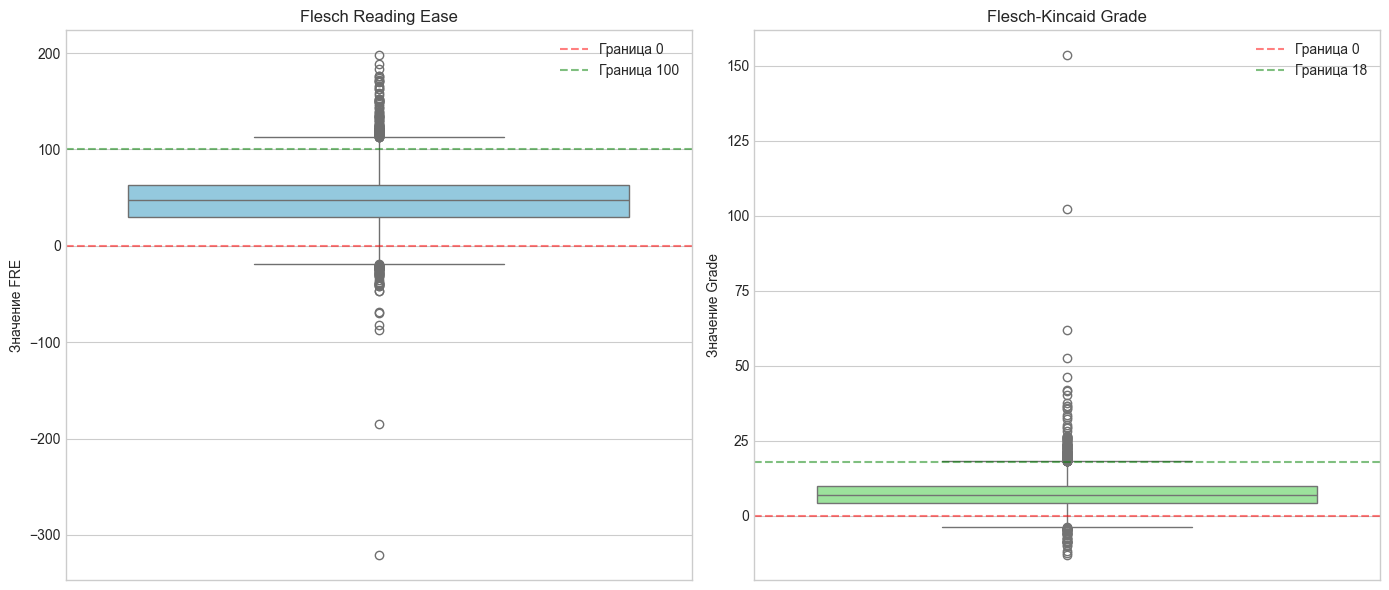

In [116]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot для FRE
sns.boxplot(y=df_text['flesch_reading_ease'], ax=axes[0], color='skyblue')
axes[0].set_title('Flesch Reading Ease', fontsize=12)
axes[0].set_ylabel('Значение FRE')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5, label='Граница 0')
axes[0].axhline(100, color='green', linestyle='--', alpha=0.5, label='Граница 100')
axes[0].legend()

# Boxplot для FKG
sns.boxplot(y=df_text['flesch_kincaid_grade'], ax=axes[1], color='lightgreen')
axes[1].set_title('Flesch-Kincaid Grade', fontsize=12)
axes[1].set_ylabel('Значение Grade')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5, label='Граница 0')
axes[1].axhline(18, color='green', linestyle='--', alpha=0.5, label='Граница 18')
axes[1].legend()

plt.tight_layout()
plt.show()

Посмотрим на статистику выбросов

In [ ]:
# FRE
q1_fre = df_text['flesch_reading_ease'].quantile(0.25)
q3_fre = df_text['flesch_reading_ease'].quantile(0.75)
iqr_fre = q3_fre - q1_fre
lower_fre = q1_fre - 1.5 * iqr_fre
upper_fre = q3_fre + 1.5 * iqr_fre

outliers_fre = df_text[(df_text['flesch_reading_ease'] < lower_fre) | (df_text['flesch_reading_ease'] > upper_fre)]
print(f"\nFRE:")
print(f"  Q1: {q1_fre:.1f}, Q3: {q3_fre:.1f}, IQR: {iqr_fre:.1f}")
print(f"  Границы усов: [{lower_fre:.1f}, {upper_fre:.1f}]")
print(f"  Выбросов: {len(outliers_fre)} ({len(outliers_fre)/len(df_text)*100:.2f}%)")
print(f"  Минимальный выброс: {outliers_fre['flesch_reading_ease'].min():.1f}")
print(f"  Максимальный выброс: {outliers_fre['flesch_reading_ease'].max():.1f}")

# FKG
q1_fkg = df_text['flesch_kincaid_grade'].quantile(0.25)
q3_fkg = df_text['flesch_kincaid_grade'].quantile(0.75)
iqr_fkg = q3_fkg - q1_fkg
lower_fkg = q1_fkg - 1.5 * iqr_fkg
upper_fkg = q3_fkg + 1.5 * iqr_fkg

outliers_fkg = df_text[(df_text['flesch_kincaid_grade'] < lower_fkg) | (df_text['flesch_kincaid_grade'] > upper_fkg)]
print(f"\nFlesch-Kincaid Grade:")
print(f"  Q1: {q1_fkg:.1f}, Q3: {q3_fkg:.1f}, IQR: {iqr_fkg:.1f}")
print(f"  Границы усов: [{lower_fkg:.1f}, {upper_fkg:.1f}]")
print(f"  Выбросов: {len(outliers_fkg)} ({len(outliers_fkg)/len(df_text)*100:.2f}%)")
print(f"  Минимальный выброс: {outliers_fkg['flesch_kincaid_grade'].min():.1f}")
print(f"  Максимальный выброс: {outliers_fkg['flesch_kincaid_grade'].max():.1f}")


FRE:
  Q1: 30.4, Q3: 63.4, IQR: 33.1
  Границы усов: [-19.2, 113.0]
  Выбросов: 160 (1.53%)
  Минимальный выброс: -320.9
  Максимальный выброс: 197.7

Flesch-Kincaid Grade:
  Q1: 4.3, Q3: 9.8, IQR: 5.5
  Границы усов: [-3.9, 18.1]
  Выбросов: 209 (1.99%)
  Минимальный выброс: -13.2
  Максимальный выброс: 153.5


Видим выбросы. Обработаем их

In [ ]:
df_text['flesch_reading_ease_capped'] = df_text['flesch_reading_ease'].clip(lower=-19.2, upper=113.0)
df_text['flesch_kincaid_grade_capped'] = df_text['flesch_kincaid_grade'].clip(lower=-3.9, upper=18.1)

print(f"Изменено FRE: {(df_text['flesch_reading_ease_capped'] != df_text['flesch_reading_ease']).sum()} значений")
print(f"Изменено Grade: {(df_text['flesch_kincaid_grade_capped'] != df_text['flesch_kincaid_grade']).sum()} значений")

Изменено FRE: 229 значений
Изменено Grade: 279 значений


Сохраняем результаты

In [119]:
columns_to_keep = [
    'channel_username', 'post_id',
    'text', 'text_clean', 'text_ruts',
    'text_length', 'text_length_clean', 'uppercase_count',
    'links_count_entities', 'has_links_entities', 'links_from_entities',
    # Оригинальные метрики (для справки)
    'n_words', 'n_sents', 'n_chars',
    'flesch_reading_ease', 'flesch_kincaid_grade', 'ttr', 'words_per_sent',
    'flesch_reading_ease_capped', 'flesch_kincaid_grade_capped'
]

existing_cols = [col for col in columns_to_keep if col in df_text.columns]
df_final = df_text[existing_cols].copy()

output_path = "../data/split/02_text_with_metrics.csv"
df_final.to_csv(output_path, index=False)